# Network-Based Connectivity Matrix Ordering

## Purpose

This notebook derives a deterministic ROI ordering from the validated
Schaefer-200 atlas network labels and applies that ordering to a
participant-level connectivity matrix.

The reordered matrix places ROIs belonging to the same canonical network
next to one another, making within-network and between-network connectivity
patterns visible.

## Scope

This notebook:

* loads the validated Schaefer-200 atlas annotation table;
* loads one validated 200 × 200 connectivity matrix;
* defines the canonical seven-network order explicitly;
* generates a deterministic 200-element ROI permutation;
* preserves the original `roi_index` order within each network;
* applies the same permutation to matrix rows and columns;
* validates the reordered matrix;
* visualizes the network-ordered matrix with network boundaries and labels.

The original connectivity matrix is not modified or overwritten.

## 1. Imports and project paths

This section imports the packages required for loading the validated atlas
annotations, locating the connectivity data, and performing quality-control
checks.

In [25]:
# Import tools for working with project paths and tabular data
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lemon_connectivity.alignment import align_participants_to_fcm
from lemon_connectivity.io import (
    edge_list_to_matrix,
    load_fcm_edge_list,
)
from lemon_connectivity.networks import (
    create_network_permutation,
    reorder_connectivity_matrix,
)

## 2. Load the validated atlas labels

The atlas annotation table produced in Issue #9 provides the biological
labels for the 200 Schaefer ROIs.

This table will be used to determine the network membership of each ROI
and to construct the deterministic ordering for the connectivity matrix.

The table is loaded as an input to this notebook and is not modified here.


In [2]:
# Find the repository root by locating pyproject.toml
current_path = Path.cwd()

repo_root = next(
    path
    for path in [current_path, *current_path.parents]
    if (path / "pyproject.toml").exists()
)

# Define the path to the validated atlas label table from Issue #9
atlas_labels_path = repo_root / "data" / "interim" / "schaefer200_7networks_labels.tsv"
# Load the validated Schaefer-200 atlas annotation table from Issue #9
atlas_labels = pd.read_csv(
    atlas_labels_path,
    sep="\t",
)

### Cohort Metadata Input
Load the cohort metadata used by the participant-to-FCM alignment workflow.


In [3]:
# Define the cohort metadata path using the repository root
cohort_path = (
    repo_root
    / "data"
    / "external"
    / "Curvature-FCN-Aging"
    / "DATA"
    / "cohort_information.tsv"
)

# Load cohort metadata with participant IDs preserved as strings
cohort_metadata = pd.read_csv(
    cohort_path,
    sep="\t",
    dtype={"sub_id": "string"},
)

## 3. Validate the atlas input

The atlas table is the validated output from Issue #9 and should contain
exactly one annotation row for each of the 200 Schaefer ROIs.

Before constructing the network ordering, this section confirms that:

* exactly 200 ROIs are present;
* `roi_index` values are unique;
* ROI indices are exactly `0–199`;
* the expected annotation columns are present;
* no required atlas annotations are missing.


In [4]:
# Define the expected ROI indices for the Schaefer-200 atlas
expected_roi_indices = set(range(200))

# Define the expected atlas annotation columns from Issue #9
expected_columns = {
    "roi_index",
    "hemisphere",
    "parcel_name",
    "canonical_network",
}

# Collect atlas validation results
atlas_qc = {
    "row_count": len(atlas_labels),
    "expected_row_count": 200,
    "roi_count": atlas_labels["roi_index"].nunique(),
    "expected_roi_count": 200,
    "roi_indices_complete": set(atlas_labels["roi_index"]) == expected_roi_indices,
    "expected_columns_present": expected_columns.issubset(atlas_labels.columns),
    "missing_required_values": atlas_labels[
        ["roi_index", "hemisphere", "parcel_name", "canonical_network"]
    ]
    .isna()
    .sum()
    .sum(),
}

# Display the validation results as a compact table
pd.Series(atlas_qc)

# Stop execution if any required atlas QC check fails
if not (
    atlas_qc["row_count"] == atlas_qc["expected_row_count"]
    and atlas_qc["roi_count"] == atlas_qc["expected_roi_count"]
    and atlas_qc["roi_indices_complete"]
    and atlas_qc["expected_columns_present"]
    and atlas_qc["missing_required_values"] == 0
):
    raise ValueError("Atlas input QC failed")

## 4. Define the canonical network order

The connectivity matrix will be reordered according to the canonical
seven-network ordering used by the project.

The ordering is defined explicitly rather than generated alphabetically.
This ensures that the same ROI permutation is produced consistently across
participants and notebook runs.

Before defining the order, the network labels present in the validated
atlas table are inspected to confirm that all expected canonical networks
are available.


In [5]:
# Inspect the unique canonical network labels in the validated atlas table
atlas_labels["canonical_network"].unique()

<StringArray>
[                    'Visual',                'Somatomotor',
           'Dorsal Attention', 'Salience/Ventral Attention',
                     'Limbic',                    'Control',
                    'Default']
Length: 7, dtype: str

### 4.1 Canonical network order

The seven canonical networks are ordered explicitly as:

1. Visual
2. Somatomotor
3. Dorsal Attention
4. Salience/Ventral Attention
5. Limbic
6. Control
7. Default

This order is fixed for the project and is not generated by alphabetical
sorting.

The same order will be used to construct the ROI permutation for every
connectivity matrix.


In [6]:
# Define the fixed canonical network order for the project
canonical_network_order = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Salience/Ventral Attention",
    "Limbic",
    "Control",
    "Default",
]

In [26]:
# Get the network labels present in the validated atlas table
observed_networks = set(atlas_labels["canonical_network"])
expected_networks = set(canonical_network_order)

# Identify networks expected by the canonical order but absent from the atlas
missing_networks = expected_networks - observed_networks

# Identify networks present in the atlas but absent from the canonical order
unexpected_networks = observed_networks - expected_networks

# Create a compact validation report
network_membership_qc = pd.Series(
    {
        "observed_network_count": len(observed_networks),
        "expected_network_count": len(expected_networks),
        "missing_networks": sorted(missing_networks),
        "unexpected_networks": sorted(unexpected_networks),
        "canonical_order_unique": (
            len(canonical_network_order) == len(expected_networks)
        ),
    }
)

pd.Series(network_membership_qc)

# Stop execution if the atlas networks do not match the canonical network order
if not (
    network_membership_qc["observed_network_count"]
    == network_membership_qc["expected_network_count"]
    and network_membership_qc["missing_networks"] == []
    and network_membership_qc["unexpected_networks"] == []
    and network_membership_qc["canonical_order_unique"]
):
    raise ValueError("Canonical network membership QC failed")

## 5. Create the deterministic ROI permutation

The ROI permutation will group regions according to the canonical network
order while preserving the original `roi_index` order within each network.

Before generating the permutation, the current ROI ordering and network
assignments are inspected so that the resulting permutation can be
validated against the atlas table.


In [8]:
# Inspect the ROI, hemisphere, and canonical network assignments
# in their current atlas order
atlas_labels[["roi_index", "hemisphere", "canonical_network"]].head(20)

,roi_index,hemisphere,canonical_network
0,0,LH,Visual
1,1,LH,Visual
2,2,LH,Visual
3,3,LH,Visual
4,4,LH,Visual
5,5,LH,Visual
6,6,LH,Visual
7,7,LH,Visual
8,8,LH,Visual
9,9,LH,Visual


### 5.1 Count ROIs in each canonical network

The number of ROIs assigned to each canonical network is calculated from the
validated atlas table.

These counts provide a quality-control reference for the expected size of
each network block in the reordered connectivity matrix.


In [9]:
# Count the number of ROIs assigned to each canonical network
network_counts = (
    atlas_labels["canonical_network"].value_counts().reindex(canonical_network_order)
)
print(network_counts.sum())
network_counts

200


canonical_network
Visual                        29
Somatomotor                   35
Dorsal Attention              26
Salience/Ventral Attention    22
Limbic                        12
Control                       30
Default                       46
Name: count, dtype: int64

## 5.2 Generate the ROI permutation

The validated atlas labels and the fixed canonical network order are passed
to the reusable `create_network_permutation()` function.

The resulting permutation contains all 200 ROI indices, grouped by canonical
network while preserving the original `roi_index` order within each network.

This permutation will later be applied identically to the rows and columns
of the connectivity matrix.


In [10]:
# Create the deterministic ROI permutation using the canonical network order
roi_permutation = create_network_permutation(
    atlas_labels,
    canonical_network_order,
)

### 5.3 Validate the ROI permutation

The generated permutation should contain exactly one entry for every
Schaefer-200 ROI.

This validation confirms that:

* the permutation contains 200 ROI indices;
* every ROI index is unique;
* the complete ROI set `0–199` is represented.

The connectivity matrix will only be reordered after these checks pass.


In [11]:
# Define the expected ROI indices for the Schaefer-200 atlas
expected_roi_indices = set(range(200))

# Collect permutation validation results
permutation_qc = {
    "permutation_length": len(roi_permutation),
    "expected_length": 200,
    "unique_roi_count": len(set(roi_permutation)),
    "expected_unique_count": 200,
    "roi_indices_complete": set(roi_permutation) == expected_roi_indices,
}

# Display the validation results
pd.Series(permutation_qc)

# Stop execution if the ROI permutation is invalid
if not (
    permutation_qc["permutation_length"] == permutation_qc["expected_length"]
    and permutation_qc["unique_roi_count"] == permutation_qc["expected_unique_count"]
    and permutation_qc["roi_indices_complete"]
):
    raise ValueError("ROI permutation QC failed")

### 5.4 Validate the network ordering

The permutation should group ROIs according to the fixed canonical network
order while preserving the original `roi_index` order within each network.

This validation checks that the network labels produced by the permutation
follow the expected canonical sequence.


In [12]:
# Get the network sequence produced by the ROI permutation
permuted_networks = (
    atlas_labels.set_index("roi_index")
    .loc[
        roi_permutation,
        "canonical_network",
    ]
    .tolist()
)

# Map each canonical network to its position in the requested order
network_positions = {
    network: index for index, network in enumerate(canonical_network_order)
}

# Convert the network sequence into canonical-order positions
network_order_values = [network_positions[network] for network in permuted_networks]

# Check that network blocks follow the canonical order
network_sequence_qc = {
    "network_sequence_valid": (network_order_values == sorted(network_order_values)),
}

pd.Series(network_sequence_qc)

# Stop execution if the network sequence does not follow the canonical order
if not network_sequence_qc["network_sequence_valid"]:
    raise ValueError("Canonical network sequence QC failed")

### 5.5 Validate the ROI order within each network

Within each canonical network, the permutation should preserve the original
`roi_index` order from the validated atlas table.

This ensures that the permutation changes the grouping of networks without
introducing a new or arbitrary ordering of ROIs within each network.


In [13]:
# Get the ROI indices in their new network-based order
permuted_roi_indices = roi_permutation

# Check that ROI indices increase within each consecutive network block
within_network_order_valid = True

start = 0

for network in canonical_network_order:
    network_count = network_counts[network]
    end = start + network_count

    network_roi_indices = permuted_roi_indices[start:end]

    if network_roi_indices != sorted(network_roi_indices):
        within_network_order_valid = False
        break

    start = end

# Display the validation result
pd.Series(
    {
        "within_network_roi_order_valid": within_network_order_valid,
    }
)

# Stop execution if ROI indices are not sorted within each network block
if not within_network_order_valid:
    raise ValueError("Within-network ROI ordering QC failed")

### 5.6 Inspect the final ROI ordering

The final ROI ordering is inspected alongside its network labels to provide
a transparent record of how the 200 ROIs will be arranged in the reordered
connectivity matrix.

Only the beginning and end of the ordering are displayed for readability.


In [14]:
# Create a table showing the ROI permutation and corresponding network labels
permutation_table = (
    atlas_labels.set_index("roi_index")
    .loc[
        roi_permutation,
        ["hemisphere", "canonical_network"],
    ]
    .reset_index()
)

# Display the beginning and end of the final ordering
pd.concat(
    [
        permutation_table.head(10),
        permutation_table.tail(10),
    ]
)

,roi_index,hemisphere,canonical_network
0,0,LH,Visual
1,1,LH,Visual
2,2,LH,Visual
3,3,LH,Visual
4,4,LH,Visual
5,5,LH,Visual
6,6,LH,Visual
7,7,LH,Visual
8,8,LH,Visual
9,9,LH,Visual


## 6. Reconstruct the Connectivity Matrix

Select one validated matched FCM file deterministically, load its edge-list
representation, and reconstruct the corresponding 200 × 200 connectivity
matrix.

The participant-level file is selected from the validated alignment table
rather than being hard-coded. The reconstructed matrix is used only to
demonstrate the network-based ordering workflow.

In [15]:
# Define the FCM directory using the repository root

fcm_data_path = repo_root / "data" / "external" / "Curvature-FCN-Aging" / "DATA" / "FCM"

# Align cohort participants with the available FCM files

alignment_result = align_participants_to_fcm(
    cohort_metadata,
    fcm_data_path,
)

# Select the first validated matched FCM file deterministically

matched_files = alignment_result.alignment_table.loc[
    alignment_result.alignment_table["alignment_status"] == "matched",
    ["matrix_filename", "matrix_path"],
].sort_values(
    ["matrix_filename", "matrix_path"],
    kind="stable",
)

if matched_files.empty:
    raise ValueError("No validated matched FCM file is available")

target_file_path = Path(matched_files.iloc[0]["matrix_path"])

# Load the selected validated FCM edge list

fcm_edges = load_fcm_edge_list(
    target_file_path,
    n_rois=200,
)

# Reconstruct the 200 × 200 connectivity matrix

connectivity_matrix = edge_list_to_matrix(
    fcm_edges,
    n_rois=200,
)

## 7. Validate the connectivity matrix

The reconstructed connectivity matrix is checked before network ordering is
applied.

The validation confirms that the matrix:

* has the expected 200 × 200 shape;
* is symmetric;
* has a diagonal value of 1.0;
* contains finite connectivity values.

These checks ensure that the matrix is structurally valid before the same ROI
permutation is applied to its rows and columns.


In [16]:
# Collect structural validation results for the reconstructed matrix
matrix_qc = {
    "shape": connectivity_matrix.shape,
    "expected_shape": (200, 200),
    "shape_valid": connectivity_matrix.shape == (200, 200),
    "symmetric": np.allclose(connectivity_matrix, connectivity_matrix.T),
    "diagonal_is_one": np.allclose(
        np.diag(connectivity_matrix),
        1.0,
    ),
    "all_values_finite": np.isfinite(connectivity_matrix).all(),
}

# Display the matrix validation results
pd.Series(matrix_qc)

# Stop execution if the original connectivity matrix fails QC
if not (
    matrix_qc["shape_valid"]
    and matrix_qc["symmetric"]
    and matrix_qc["diagonal_is_one"]
    and matrix_qc["all_values_finite"]
):
    raise ValueError("Original connectivity matrix QC failed")

## 8. Apply the ROI permutation

The validated ROI permutation is applied to the connectivity matrix using the
reusable `reorder_connectivity_matrix()` function.

The same permutation is applied to both matrix rows and columns. This moves
each ROI into its canonical network position while preserving the original
connectivity relationships between ROIs.

The original connectivity matrix remains unchanged.


In [17]:
# Apply the validated ROI permutation to both matrix axes
reordered_matrix = reorder_connectivity_matrix(
    connectivity_matrix,
    roi_permutation,
)

## 9. Validate the reordered matrix

The reordered connectivity matrix is validated to confirm that applying the
ROI permutation changed only the arrangement of rows and columns.

The reordered matrix should:

* retain the 200 × 200 shape;
* remain symmetric;
* retain a diagonal value of 1.0;
* contain the same connectivity values as the original matrix.


In [18]:
# Construct the inverse permutation to restore the original ROI order
inverse_permutation = np.argsort(roi_permutation)

# Restore the reordered matrix to its original ROI ordering
restored_matrix = reordered_matrix[np.ix_(inverse_permutation, inverse_permutation)]

# Check that restoring the permutation reproduces the original matrix exactly
values_preserved = np.array_equal(
    restored_matrix,
    connectivity_matrix,
)

reordered_matrix_qc = {
    "shape": reordered_matrix.shape,
    "expected_shape": (200, 200),
    "shape_valid": reordered_matrix.shape == (200, 200),
    "symmetric": np.allclose(
        reordered_matrix,
        reordered_matrix.T,
    ),
    "diagonal_is_one": np.allclose(
        np.diag(reordered_matrix),
        1.0,
    ),
    "all_values_finite": np.isfinite(reordered_matrix).all(),
    "values_preserved": values_preserved,
}

pd.Series(reordered_matrix_qc)

# Stop execution if the reordered connectivity matrix fails QC
if not (
    reordered_matrix_qc["shape_valid"]
    and reordered_matrix_qc["symmetric"]
    and reordered_matrix_qc["diagonal_is_one"]
    and reordered_matrix_qc["all_values_finite"]
    and reordered_matrix_qc["values_preserved"]
):
    raise ValueError("Reordered connectivity matrix QC failed")

## 10. Define the network boundaries

The reordered ROI sequence places each canonical network into a contiguous
block.

Network boundaries are derived from the validated network counts rather than
hard-coded matrix positions. These boundaries identify where each network
block ends in the 200 × 200 reordered matrix and will be used to annotate the
heatmap.


In [19]:
# Calculate the cumulative end position of each network block
network_boundaries = network_counts.cumsum()

# Display the network boundaries
network_boundaries

canonical_network
Visual                         29
Somatomotor                    64
Dorsal Attention               90
Salience/Ventral Attention    112
Limbic                        124
Control                       154
Default                       200
Name: count, dtype: int64

## 11. Prepare the heatmap labels

The reordered atlas annotations are used to identify the network associated
with each row and column of the reordered connectivity matrix.

The network labels are aligned with the same ROI permutation used to reorder
the matrix. This ensures that the network boundaries and labels correspond
to the correct matrix blocks.


In [20]:
# Reorder the atlas labels using the same ROI permutation as the matrix
reordered_labels = (
    atlas_labels.set_index("roi_index").loc[roi_permutation].reset_index()
)

# Keep the network labels in the same order as the reordered matrix
reordered_networks = reordered_labels["canonical_network"].tolist()

## 12. Visualize the network-ordered matrix

The reordered connectivity matrix is displayed as a heatmap to visualize
within-network and between-network connectivity patterns.

Network boundaries are drawn using the validated cumulative network
positions, and each block is labelled with its corresponding canonical
network.

The visualization uses the reordered matrix only; the original connectivity
matrix remains unchanged.


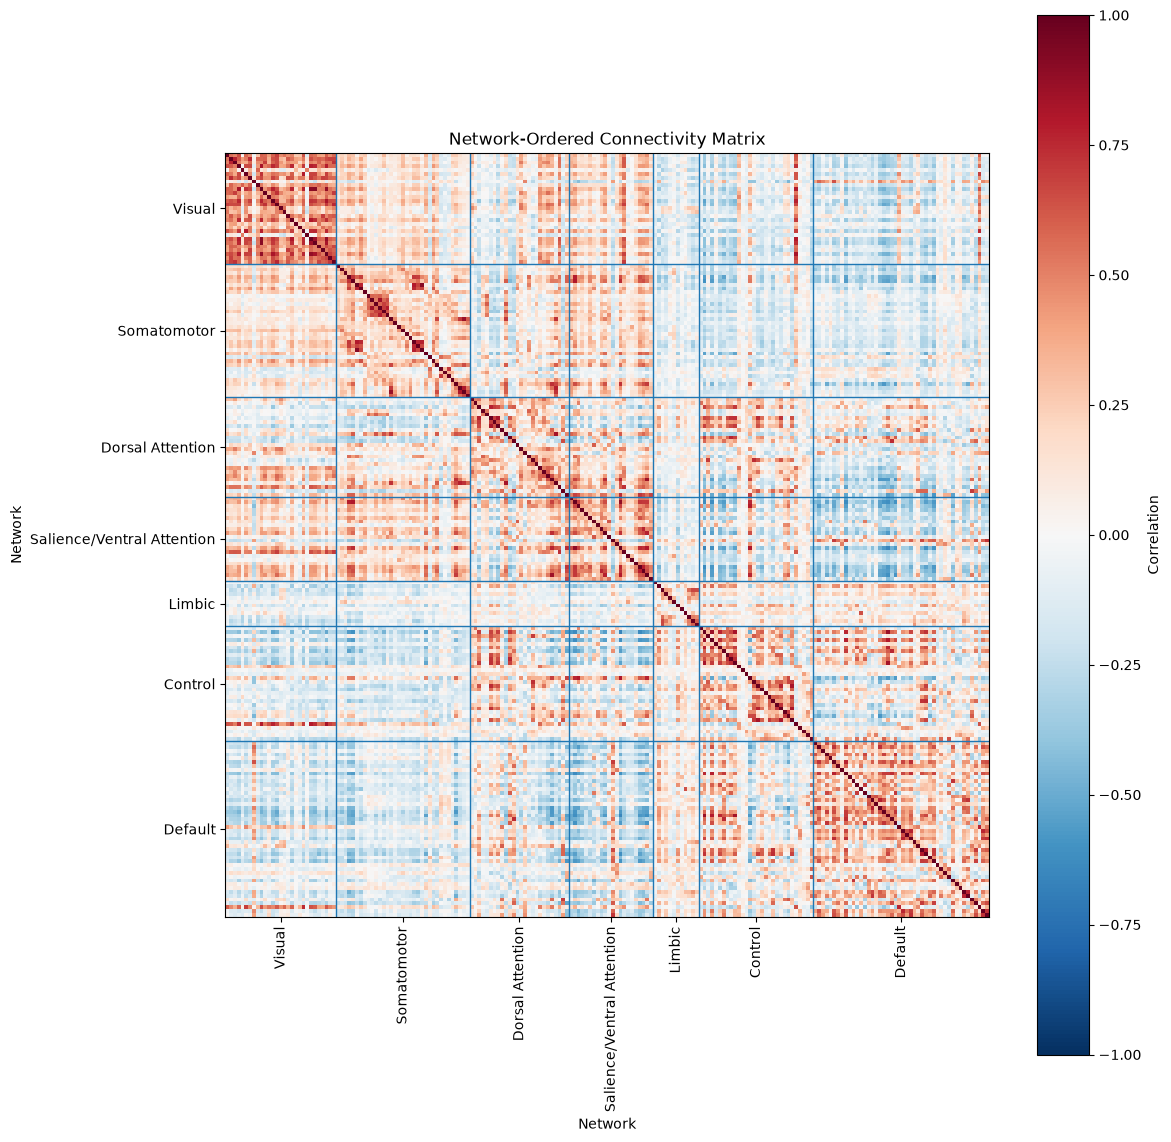

In [21]:
# Plot the network-ordered connectivity matrix

fig, ax = plt.subplots(figsize=(12, 12))

image = ax.imshow(
    reordered_matrix,
    aspect="equal",
    interpolation="none",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

# Add network boundaries on both axes
for boundary in network_boundaries.iloc[:-1]:
    ax.axhline(
        boundary - 0.5,
        linewidth=1,
    )
    ax.axvline(
        boundary - 0.5,
        linewidth=1,
    )

# Calculate the center of each network block
network_starts = [0] + network_boundaries.iloc[:-1].tolist()
network_ends = network_boundaries.tolist()

network_centers = [
    (start + end - 1) / 2
    for start, end in zip(
        network_starts,
        network_ends,
    )
]

# Label networks on both axes
ax.set_xticks(network_centers)
ax.set_xticklabels(
    canonical_network_order,
    rotation=90,
)

ax.set_yticks(network_centers)
ax.set_yticklabels(
    canonical_network_order,
)

ax.set_xlabel("Network")
ax.set_ylabel("Network")

ax.set_title("Network-Ordered Connectivity Matrix")

# Add a colorbar for correlation values
colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label("Correlation")

plt.tight_layout()
plt.show()

## 13. Validate the network boundaries

The network boundaries should agree with the reordered atlas labels.

For each canonical network, we check that the corresponding section of the reordered labels contains only that network and has the expected number of ROIs.

This confirms that the heatmap boundaries are aligned with the actual network assignments.


In [22]:
# Validate that each network occupies its expected contiguous block
boundary_qc = {}

start = 0

for network in canonical_network_order:
    end = network_boundaries[network]

    block_networks = reordered_networks[start:end]

    boundary_qc[network] = len(block_networks) == network_counts[network] and all(
        label == network for label in block_networks
    )

    start = end

pd.Series(boundary_qc)

# Stop execution if any network boundary does not match the reordered labels
if not all(boundary_qc.values()):
    raise ValueError("Network boundary QC failed")

## 14. Confirm the original matrix is preserved

The network ordering operation should create a new matrix rather than overwrite the original connectivity matrix.

We therefore verify that the original matrix still has the same values after reordering.


In [23]:
# Verify that the original connectivity matrix is unchanged
original_matrix_preserved = np.array_equal(
    connectivity_matrix,
    edge_list_to_matrix(
        fcm_edges,
        n_rois=200,
    ),
)

pd.Series(
    {
        "original_matrix_preserved": original_matrix_preserved,
    }
)

# Stop execution if the original connectivity matrix was modified
if not original_matrix_preserved:
    raise ValueError("Original connectivity matrix preservation QC failed")

## 15. Final network-ordering quality control

This final summary combines the structural checks performed throughout the notebook.

The reordered matrix must contain all 200 ROIs exactly once, follow the canonical network order, remain symmetric, preserve its values, and agree with the validated network boundaries.


In [24]:
# Final network-ordering quality-control summary

final_qc = {
    "permutation_length_valid": (
        permutation_qc["permutation_length"] == permutation_qc["expected_length"]
    ),
    "permutation_unique": (
        permutation_qc["unique_roi_count"] == permutation_qc["expected_unique_count"]
    ),
    "permutation_complete": permutation_qc["roi_indices_complete"],
    "network_sequence_valid": network_sequence_qc["network_sequence_valid"],
    "within_network_order_valid": within_network_order_valid,
    "original_matrix_shape_valid": matrix_qc["shape_valid"],
    "original_matrix_symmetric": matrix_qc["symmetric"],
    "original_matrix_diagonal_valid": matrix_qc["diagonal_is_one"],
    "original_matrix_finite": matrix_qc["all_values_finite"],
    "reordered_matrix_shape_valid": reordered_matrix_qc["shape_valid"],
    "reordered_matrix_symmetric": reordered_matrix_qc["symmetric"],
    "reordered_matrix_diagonal_valid": reordered_matrix_qc["diagonal_is_one"],
    "reordered_matrix_finite": reordered_matrix_qc["all_values_finite"],
    "values_preserved": reordered_matrix_qc["values_preserved"],
    "network_boundaries_valid": all(boundary_qc.values()),
    "original_matrix_preserved": original_matrix_preserved,
}

final_qc = pd.Series(final_qc)

display(final_qc)

if not final_qc.all():
    raise ValueError("Final network-ordering QC failed")

permutation_length_valid           True
permutation_unique                 True
permutation_complete               True
network_sequence_valid             True
within_network_order_valid         True
original_matrix_shape_valid        True
original_matrix_symmetric          True
original_matrix_diagonal_valid     True
original_matrix_finite             True
reordered_matrix_shape_valid       True
reordered_matrix_symmetric         True
reordered_matrix_diagonal_valid    True
reordered_matrix_finite            True
values_preserved                   True
network_boundaries_valid           True
original_matrix_preserved          True
dtype: bool

## Summary

This notebook established a deterministic network-based ordering of the validated Schaefer-200 connectivity matrix.

The workflow:

* Loaded the validated Schaefer-200 atlas labels.
* Defined the canonical seven-network order.
* Created and validated a deterministic 200-ROI permutation.
* Preserved the original ROI order within each network.
* Reconstructed the validated 200 × 200 connectivity matrix.
* Reordered the matrix using the same permutation for rows and columns.
* Verified that the reordered matrix remains symmetric and preserves all connectivity values.
* Defined network boundaries from the validated network counts.
* Verified that the boundaries agree with the reordered atlas labels.
* Confirmed that the original connectivity matrix was not overwritten.
* Visualized the network-ordered connectivity matrix with network boundaries and labels.

All network-ordering quality-control checks passed.
